# Georgiev et al. comparison + three-way validation

Overplots this pipeline's three kSZ results (stitched, coeval-direct,
coeval-Georgiev-reconstruction) against **Georgiev et al.'s own published
parameter-study data** (`obs_vs_params_xe_ksz_data.pickle`) -- a semi-analytic
model swept over 4 reionization-history parameters (`zre`, `zend`, `alpha0`,
`kappa`), 3 test values each, giving 12 (xe(z), D_ell) curve pairs total.

**Naming note, read before editing:** "coeval-Georgiev" elsewhere in this
repo means *our own* reconstruction of P_qperp from Pee/Pvv/Pev via the
Georgiev+24 Eq.(10) convolution (see `georgiev_convolution.py`) -- that is
NOT the same thing as the data loaded in this notebook, which is Georgiev
et al.'s actual published model curves. Both appear on the same plots below;
they are labeled distinctly (`ours (Georgiev-Eq10 recon)` vs
`Georgiev+24 (param sweep)`) specifically to avoid conflating them.

No new science logic here (per `README.md`'s "no science logic" convention
for `notebooks/exploratory/`) -- this only loads already-computed products
and plots/compares them.

In [1]:
import os
import pickle
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colors

plt.rcParams.update({'font.family': 'serif', 'font.size': 12, 'axes.linewidth': 1.3})

# ---- paths -- ADJUST THESE if your layout differs ----
PRODUCTS_DIR = "../../data/products"
GEORGIEV_PICKLE = "../../data/external/georgiev/obs_vs_params_xe_ksz_data.pickle"
PLOTS_DIR = "../../data/plots"
# ^ data/plots/ is referenced in configs/fiducial.yaml but never created by
#   any script (only data/cache/ and data/products/ get os.makedirs'd) --
#   make it here so a fresh clone doesn't crash on the first savefig() below.
os.makedirs(PLOTS_DIR, exist_ok=True)

In [2]:
# ---- load our own three results ----
coeval   = np.load(f"{PRODUCTS_DIR}/ksz_Dl_coeval.npz")
georgiev_recon = np.load(f"{PRODUCTS_DIR}/ksz_Dl_coeval_georgiev.npz")  # OUR reconstruction, not Georgiev's data
stitched = np.load(f"{PRODUCTS_DIR}/ksz_Dl_stitched.npz")
reion    = np.load(f"{PRODUCTS_DIR}/coeval_reion.npz")

print("coeval-direct   D_3000 =", float(np.interp(3000, coeval['ell'], coeval['Dl'])), "uK^2")
print("coeval-Georgiev D_3000 =", float(np.interp(3000, georgiev_recon['ell'], georgiev_recon['Dl'])), "uK^2  (our Eq.10 reconstruction)")
print("stitched        D_3000 =", float(np.interp(3000, stitched['ell'], stitched['Dl'])), "uK^2")
print("coeval_reion z-range (patchy):", reion['z'].min(), "-", reion['z'].max())

coeval-direct   D_3000 = 1.8440969514209002 uK^2
coeval-Georgiev D_3000 = 5.124496028635617 uK^2  (our Eq.10 reconstruction)
stitched        D_3000 = 0.8068945728938441 uK^2
coeval_reion z-range (patchy): 4.5 - 18.0


In [3]:
# ---- load Georgiev et al.'s published parameter-study data ----
with open(GEORGIEV_PICKLE, 'rb') as f:
    geo = pickle.load(f)

zlin        = geo['zlin']          # (100,) redshift grid, 0-20
lrange      = geo['lrange']        # (100,) multipole grid, 100-10000 (not evenly log-spaced)
ndeg        = geo['ndeg']          # 4 parameters
ntest       = geo['ntest']         # 3 test values per parameter
labels      = geo['labels']        # LaTeX labels, e.g. r'$z_\mathrm{re}$'
paramnames  = geo['paramnames']    # ['zre', 'zend', 'alpha0', 'kappa']
results     = geo['results']       # dict keyed 0..ndeg-1

print(f"{ndeg} parameters x {ntest} test values each:", paramnames)

4 parameters x 3 test values each: ['zre', 'zend', 'alpha0', 'kappa']


## D_ell(ell) overlay

Each row is one of Georgiev's 4 swept parameters (others held fixed);
each faint line is one of their 3 test values for that parameter. Our
three curves (same on every row, since they don't vary by *their*
parameter grid) show where this pipeline's fiducial run sits relative
to the region of parameter space they explored.

Saved -> ../../data/plots/georgiev_comparison_Dell.pdf


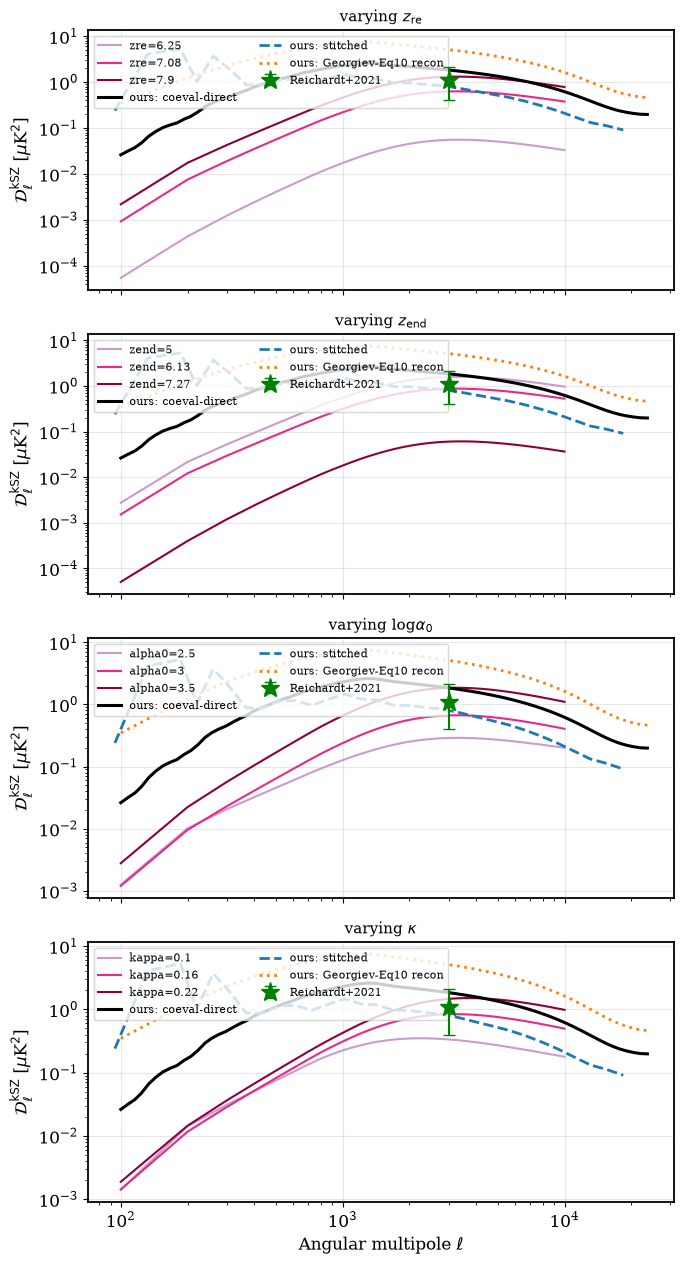

In [4]:
fig, axes = plt.subplots(ndeg, 1, figsize=(7, 3.2 * ndeg), sharex=True)

for i in range(ndeg):
    ax = axes[i]
    cmap = mpl.colormaps['PuRd']
    norm = colors.Normalize(vmin=geo['params_test'][:, i].min(),
                             vmax=geo['params_test'][:, i].max())

    for u in range(ntest):
        theta = results[i]['theta'][u]
        ax.plot(lrange, results[i]['ksz'][u], color=cmap(0.35 + 0.55 * norm(theta[i])),
                 lw=1.5, label=f"{paramnames[i]}={theta[i]:.3g}")

    # our three results, same on every row
    ax.plot(coeval['ell'], coeval['Dl'], color='k', lw=2.2, ls='-', label='ours: coeval-direct')
    ax.plot(stitched['ell'], stitched['Dl'], color='tab:blue', lw=2.0, ls='--', label='ours: stitched')
    ax.plot(georgiev_recon['ell'], georgiev_recon['Dl'], color='tab:orange', lw=2.0, ls=':',
             label='ours: Georgiev-Eq10 recon')

    # Reichardt+2021 anchor point
    ax.errorbar([3000], [1.1], yerr=[[0.7], [1.0]], fmt='*', color='green',
                 markersize=14, capsize=4, label='Reichardt+2021', zorder=10)

    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_ylabel(r"$\mathcal{D}_\ell^\mathrm{kSZ}$ [$\mu$K$^2$]")
    ax.set_title(f"varying {labels[i]}", fontsize=11)
    ax.legend(fontsize=8, ncol=2, loc='upper left')
    ax.grid(alpha=0.3)

axes[-1].set_xlabel(r"Angular multipole $\ell$")
fig.tight_layout()
fig.savefig(f"{PLOTS_DIR}/georgiev_comparison_Dell.pdf")
print(f"Saved -> {PLOTS_DIR}/georgiev_comparison_Dell.pdf")

## Ionization history x_e(z) overlay

Same layout: Georgiev's swept parameter families vs. our own reionization
history from `coeval_reion.npz`.

Saved -> ../../data/plots/georgiev_comparison_xe.pdf


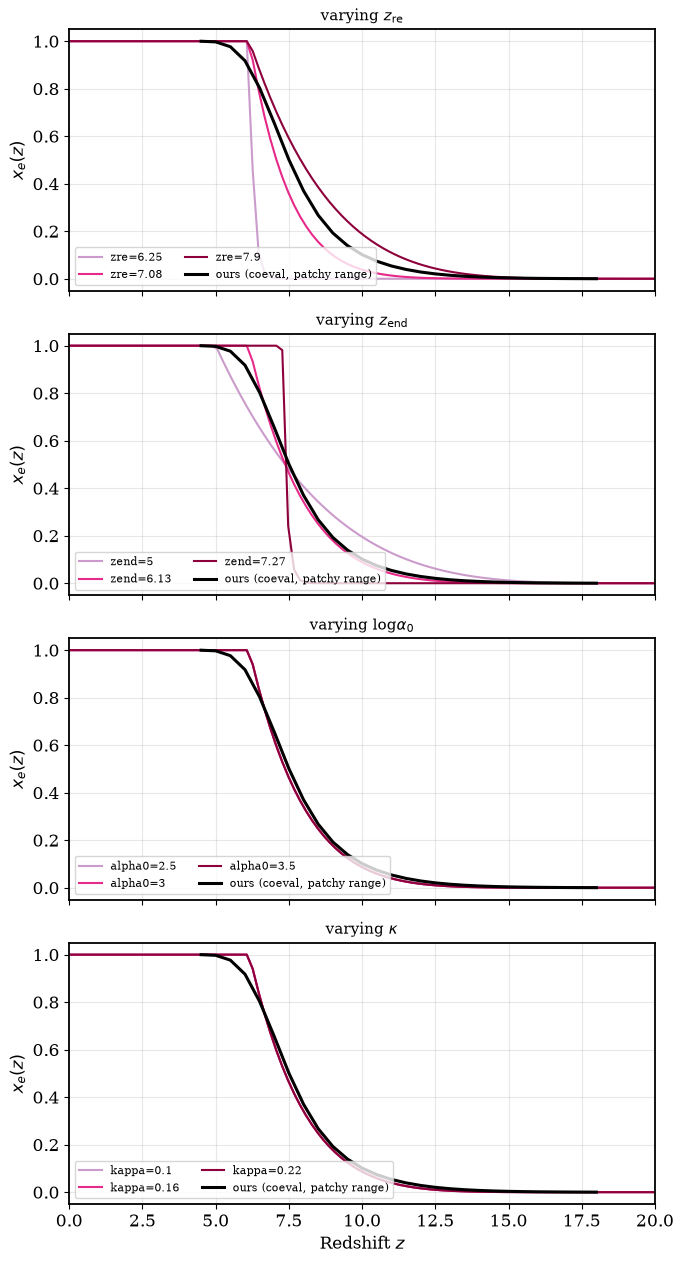

In [5]:
our_z  = reion['z']
our_xe = reion['xe']

fig, axes = plt.subplots(ndeg, 1, figsize=(7, 3.2 * ndeg), sharex=True)

for i in range(ndeg):
    ax = axes[i]
    cmap = mpl.colormaps['PuRd']
    norm = colors.Normalize(vmin=geo['params_test'][:, i].min(),
                             vmax=geo['params_test'][:, i].max())

    for u in range(ntest):
        theta = results[i]['theta'][u]
        ax.plot(zlin, results[i]['xe'][u], color=cmap(0.35 + 0.55 * norm(theta[i])),
                 lw=1.5, label=f"{paramnames[i]}={theta[i]:.3g}")

    ax.plot(our_z, our_xe, color='k', lw=2.2, label='ours (coeval, patchy range)')

    ax.set_ylabel(r"$x_e(z)$")
    ax.set_title(f"varying {labels[i]}", fontsize=11)
    ax.legend(fontsize=8, ncol=2, loc='lower left')
    ax.grid(alpha=0.3)
    ax.set_xlim(0, 20)

axes[-1].set_xlabel(r"Redshift $z$")
fig.tight_layout()
fig.savefig(f"{PLOTS_DIR}/georgiev_comparison_xe.pdf")
print(f"Saved -> {PLOTS_DIR}/georgiev_comparison_xe.pdf")

## D_ell ratio diagnostics (for the validation table)

Same two open questions as the handoff doc:
1. stitched / coeval-direct -- flat vs ell (normalization) or ell-dependent (shape)?
2. coeval-direct / our-Georgiev-reconstruction -- confirming the ~3x overshoot, vs ell and vs redshift.

stitched/coeval-direct ratio: range 0.3354637139175477 - 62.11849513596396  (max/min = 185.17202474909647 )
 -> ELL-DEPENDENT (shape)


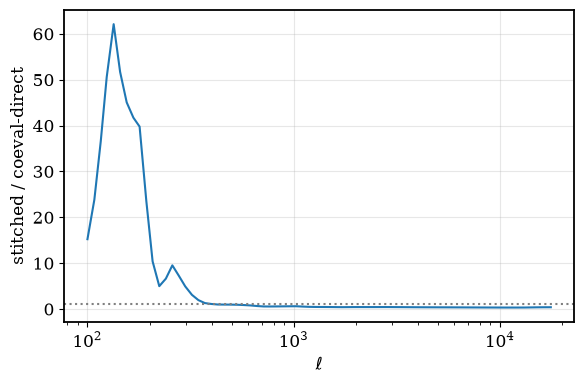

In [6]:
def loglog_interp(xq, xp, fp):
    xp, fp = np.asarray(xp), np.asarray(fp)
    m = (xp > 0) & (fp > 0)
    lx, lf = np.log(xp[m]), np.log(fp[m])
    lq = np.log(np.clip(xq, xp[m].min(), xp[m].max()))
    return np.exp(np.interp(lq, lx, lf))

# 1. stitched vs coeval-direct
lo, hi = max(coeval['ell'].min(), stitched['ell'].min()), min(coeval['ell'].max(), stitched['ell'].max())
ell_c = coeval['ell'][(coeval['ell'] >= lo) & (coeval['ell'] <= hi)]
ratio_stitch = loglog_interp(ell_c, stitched['ell'], stitched['Dl']) / loglog_interp(ell_c, coeval['ell'], coeval['Dl'])

print("stitched/coeval-direct ratio: range", ratio_stitch.min(), "-", ratio_stitch.max(),
      " (max/min =", ratio_stitch.max()/ratio_stitch.min(), ")")
print(" -> FLAT (normalization)" if ratio_stitch.max()/ratio_stitch.min() < 1.3 else " -> ELL-DEPENDENT (shape)")

plt.figure(figsize=(6,4))
plt.plot(ell_c, ratio_stitch)
plt.axhline(1.0, color='gray', ls=':')
plt.xscale('log'); plt.xlabel(r"$\ell$"); plt.ylabel("stitched / coeval-direct")
plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/ratio_stitched_vs_coeval.pdf")

In [7]:
# 2. our Georgiev-reconstruction vs coeval-direct, vs ell and vs redshift
lo_g, hi_g = max(coeval['ell'].min(), georgiev_recon['ell'].min()), min(coeval['ell'].max(), georgiev_recon['ell'].max())
ell_g = coeval['ell'][(coeval['ell'] >= lo_g) & (coeval['ell'] <= hi_g)]
ratio_g_ell = loglog_interp(ell_g, coeval['ell'], coeval['Dl']) / loglog_interp(ell_g, georgiev_recon['ell'], georgiev_recon['Dl'])

print("direct/reconstructed ratio vs ell: range", ratio_g_ell.min(), "-", ratio_g_ell.max())

pee = np.load(f"{PRODUCTS_DIR}/pee_pvv_pev.npz")
print()
print("per-redshift direct/reconstructed ratio (pre-Limber, Pqperp level):")
for i, z in enumerate(pee['z']):
    key = f"ratio_{i}"
    if key in pee:
        r = pee[key]
        print(f"  z={z:5.1f}: mean={r.mean():.3f}  range=[{r.min():.3f}, {r.max():.3f}]")

direct/reconstructed ratio vs ell: range 0.07544863558419217 - 0.4288139857222849

per-redshift direct/reconstructed ratio (pre-Limber, Pqperp level):
  z=  4.0: mean=0.303  range=[0.054, 0.655]
  z=  4.5: mean=0.311  range=[0.053, 0.822]
  z=  5.0: mean=0.318  range=[0.029, 0.873]
  z=  5.5: mean=0.339  range=[0.022, 0.714]
  z=  6.0: mean=0.365  range=[0.106, 0.621]
  z=  6.5: mean=0.321  range=[0.033, 0.536]
  z=  7.0: mean=0.325  range=[0.028, 0.515]
  z=  7.5: mean=0.325  range=[0.025, 0.491]
  z=  8.0: mean=0.315  range=[0.010, 0.464]
  z=  8.5: mean=0.298  range=[0.043, 0.453]
  z=  9.0: mean=0.311  range=[0.040, 0.455]
  z=  9.5: mean=0.324  range=[0.065, 0.439]
  z= 10.0: mean=0.281  range=[0.024, 0.419]
  z= 10.5: mean=0.297  range=[0.045, 0.423]
  z= 11.0: mean=0.292  range=[0.030, 0.412]
  z= 11.5: mean=0.282  range=[0.029, 0.398]
  z= 12.0: mean=0.275  range=[0.042, 0.402]
  z= 12.5: mean=0.271  range=[0.024, 0.388]
  z= 13.0: mean=0.282  range=[0.043, 0.384]
  z= 13.5: me

In [8]:
# Shaw et al. 2012, Tables 2 & 3 -- fiducial cosmology sigma8=0.82, zrei=10
shaw_ell = np.array([1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000])
shaw_NR  = np.array([1.97, 2.82, 3.24, 3.49, 3.66, 3.77, 3.85, 3.90, 3.93, 3.95])
shaw_CSF = np.array([1.43, 2.00, 2.19, 2.27, 2.32, 2.36, 2.40, 2.44, 2.48, 2.52])

# zrei scaling exponents alpha(ell), D_ell ~ zrei^alpha, from the same tables
shaw_zrei_exp_NR  = np.array([0.46, 0.46, 0.43, 0.40, 0.37, 0.34, 0.32, 0.30, 0.29, 0.28])
shaw_zrei_exp_CSF = np.array([0.63, 0.66, 0.64, 0.60, 0.55, 0.52, 0.48, 0.45, 0.42, 0.40])
ZREI_SHAW_FIDUCIAL = 10.0

# Our own "fully ionized" point -- dynamically pulled, not hardcoded
zrei_ours = float(reion['z'].min())
print(f"Our patchy regime's low-z edge (= effective zrei): {zrei_ours:.2f}")
print(f"(Shaw calibrated the zrei exponent over 8-12 -- {zrei_ours:.1f} is an extrapolation, treat as approximate)")

rescale_NR  = (zrei_ours / ZREI_SHAW_FIDUCIAL) ** shaw_zrei_exp_NR
rescale_CSF = (zrei_ours / ZREI_SHAW_FIDUCIAL) ** shaw_zrei_exp_CSF

shaw_NR_corrected  = shaw_NR  * rescale_NR
shaw_CSF_corrected = shaw_CSF * rescale_CSF

print()
print(f"{'ell':>6s} {'NR (zrei=10)':>13s} {'NR (ours)':>10s} {'CSF (zrei=10)':>14s} {'CSF (ours)':>11s}")
for i, ell in enumerate(shaw_ell):
    print(f"{ell:6d} {shaw_NR[i]:13.3f} {shaw_NR_corrected[i]:10.3f} "
          f"{shaw_CSF[i]:14.3f} {shaw_CSF_corrected[i]:11.3f}")

Our patchy regime's low-z edge (= effective zrei): 4.50
(Shaw calibrated the zrei exponent over 8-12 -- 4.5 is an extrapolation, treat as approximate)

   ell  NR (zrei=10)  NR (ours)  CSF (zrei=10)  CSF (ours)
  1000         1.970      1.364          1.430       0.865
  2000         2.820      1.953          2.000       1.181
  3000         3.240      2.298          2.190       1.314
  4000         3.490      2.536          2.270       1.406
  5000         3.660      2.724          2.320       1.495
  6000         3.770      2.874          2.360       1.558
  7000         3.850      2.982          2.400       1.636
  8000         3.900      3.069          2.440       1.703
  9000         3.930      3.118          2.480       1.773
 10000         3.950      3.159          2.520       1.831


In [9]:
# Chaubal et al. 2026, Table 5 -- total kSZ D_ell [uK^2], tabulated at select ell
spt_ell = np.array([2000, 3000, 4000, 5000, 6000])
spt_freeCIB_G15SZ_mean  = np.array([1.7, 1.75, 1.67, 1.6, 1.6])
spt_freeCIB_G15SZ_sigma = np.array([1.3, 0.86, 0.96, 1.1, 1.3])
spt_freeCIBSZ_mean  = np.array([2.1, 2.4, 2.72, 3.36, 2.3])
spt_freeCIBSZ_sigma = np.array([1.6, 1.0, 0.70, 0.90, 1.0])

# Single-ell=3000 points
spt_agora_mean, spt_agora_sigma = 3.96, 0.82       # Chaubal Table 5, Agora templates
act_dr6_mean,   act_dr6_sigma   = 2.0,  0.9        # Chaubal intro, citing Louis/Beringue 2025

# Homogeneous-kSZ subtraction amplitude, Chaubal Eq 8.1: D_3000^hkSZ = 1.65*(sigma8/0.8)^4.46
hkSZ_high = 1.84   # sigma8=0.812 (Planck), used for the "template" cases per Aggarwal's text
hkSZ_low  = 0.85   # AGORA-simulation estimate (Omori 2024), used for the conservative case

print("Real total-kSZ points loaded (Chaubal et al. 2026, Table 5 + intro).")

Real total-kSZ points loaded (Chaubal et al. 2026, Table 5 + intro).


Saved -> ../../data/plots/total_ksz_vs_observations.pdf


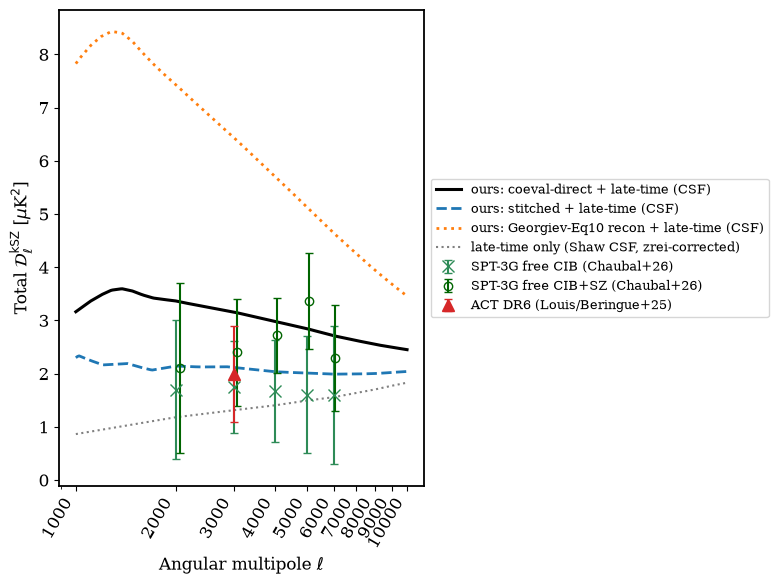

In [18]:
from matplotlib.ticker import NullFormatter

late_interp = lambda ell: loglog_interp(ell, shaw_ell, shaw_CSF_corrected)

ell_plot = np.geomspace(1000, 10000, 200)
total_coeval_direct = loglog_interp(ell_plot, coeval['ell'], coeval['Dl']) + late_interp(ell_plot)
total_stitched       = loglog_interp(ell_plot, stitched['ell'], stitched['Dl']) + late_interp(ell_plot)
total_georgiev_recon = loglog_interp(ell_plot, georgiev_recon['ell'], georgiev_recon['Dl']) + late_interp(ell_plot)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(ell_plot, total_coeval_direct, color='k', lw=2.2, label='ours: coeval-direct + late-time (CSF)')
ax.plot(ell_plot, total_stitched, color='tab:blue', lw=2.0, ls='--', label='ours: stitched + late-time (CSF)')
ax.plot(ell_plot, total_georgiev_recon, color='tab:orange', lw=2.0, ls=':', label='ours: Georgiev-Eq10 recon + late-time (CSF)')
ax.plot(shaw_ell, shaw_CSF_corrected, color='gray', lw=1.5, ls=':', label='late-time only (Shaw CSF, zrei-corrected)')

ax.errorbar(spt_ell, spt_freeCIB_G15SZ_mean, yerr=spt_freeCIB_G15SZ_sigma,
            fmt='x', color='seagreen', markersize=8, capsize=3, label='SPT-3G free CIB (Chaubal+26)')
ax.errorbar(spt_ell + 60, spt_freeCIBSZ_mean, yerr=spt_freeCIBSZ_sigma,
            fmt='o', color='darkgreen', markersize=6, capsize=3, mfc='none', label='SPT-3G free CIB+SZ (Chaubal+26)')
ax.errorbar([3000], [act_dr6_mean], yerr=[[act_dr6_sigma], [act_dr6_sigma]],
            fmt='^', color='tab:red', markersize=9, capsize=3, label='ACT DR6 (Louis/Beringue+25)')

ax.set_xscale('log')
xticks = [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]
ax.set_xticks(xticks)
ax.set_xticklabels([str(x) for x in xticks], rotation=60, ha='right')
ax.xaxis.set_minor_formatter(NullFormatter())
ax.set_xlabel(r"Angular multipole $\ell$")
ax.set_ylabel(r"Total $\mathcal{D}_\ell^\mathrm{kSZ}$ [$\mu$K$^2$]")
ax.legend(fontsize=9, loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0)
fig.tight_layout()
fig.savefig(f"{PLOTS_DIR}/total_ksz_vs_observations.pdf", bbox_inches='tight')
print(f"Saved -> {PLOTS_DIR}/total_ksz_vs_observations.pdf")

Reconstructed patchy 2-sigma upper limits at ell=3000 (compare to Fig.4 arrows):
  SPT-3G Agora            : 3.76 uK^2
  SPT-3G Agora w/ low hkSZ: 4.75 uK^2
  SPT-3G free CIB+SZ      : 2.56 uK^2
  ACT DR6                 : 2.95 uK^2

Saved -> ../../data/plots/patchy_ksz_vs_aggarwal_limits.pdf


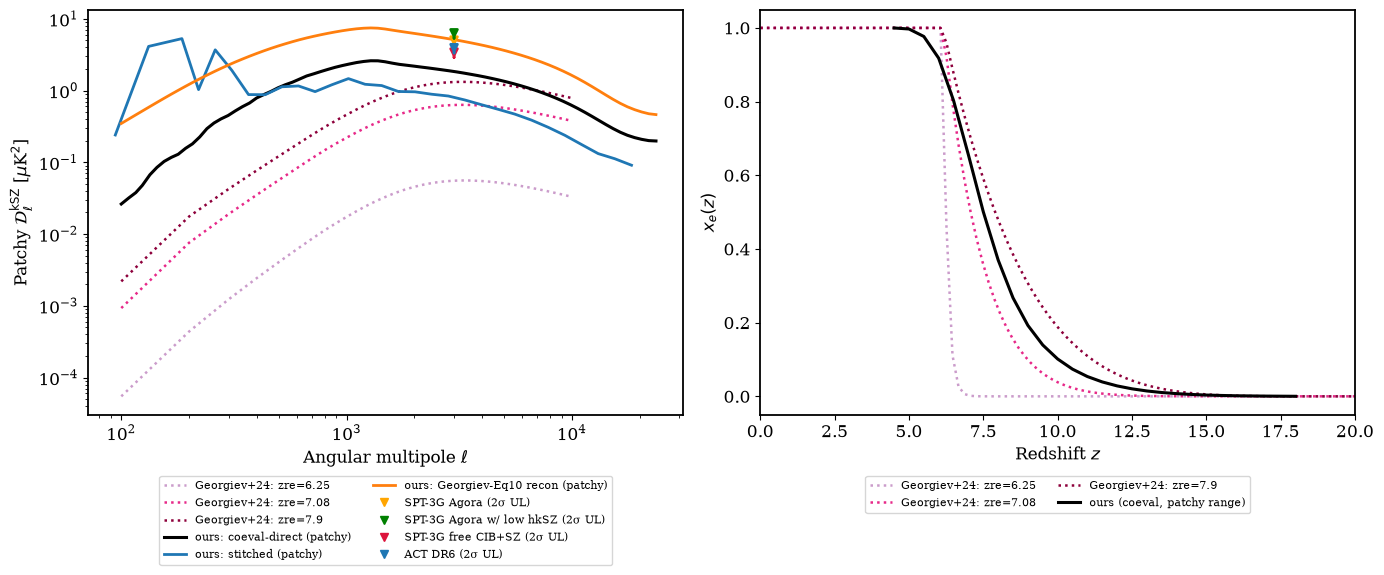

In [17]:
idx_zre = paramnames.index('zre')   # dynamic, not hardcoded -- matches the pickle's own ordering

def patchy_upper_limit(mean, sigma, hksz):
    return mean + 2 * sigma - hksz

agora_UL         = patchy_upper_limit(spt_agora_mean, spt_agora_sigma, hkSZ_high)
agora_lowhksz_UL = patchy_upper_limit(spt_agora_mean, spt_agora_sigma, hkSZ_low)
freeCIBSZ_UL     = patchy_upper_limit(spt_freeCIBSZ_mean[1], spt_freeCIBSZ_sigma[1], hkSZ_high)  # ell=3000 entry
act_UL           = patchy_upper_limit(act_dr6_mean, act_dr6_sigma, hkSZ_low)

print("Reconstructed patchy 2-sigma upper limits at ell=3000 (compare to Fig.4 arrows):")
print(f"  SPT-3G Agora            : {agora_UL:.2f} uK^2")
print(f"  SPT-3G Agora w/ low hkSZ: {agora_lowhksz_UL:.2f} uK^2")
print(f"  SPT-3G free CIB+SZ      : {freeCIBSZ_UL:.2f} uK^2")
print(f"  ACT DR6                 : {act_UL:.2f} uK^2")

fig, (ax_ksz, ax_xe) = plt.subplots(1, 2, figsize=(14, 6))

cmap = mpl.colormaps['PuRd']
norm = colors.Normalize(vmin=geo['params_test'][:, idx_zre].min(),
                         vmax=geo['params_test'][:, idx_zre].max())

# ---- left: patchy kSZ -- ours (solid) vs Georgiev+24's own zre sweep (dotted) ----
for u in range(ntest):
    theta = results[idx_zre]['theta'][u]
    ax_ksz.plot(lrange, results[idx_zre]['ksz'][u], color=cmap(0.35 + 0.55 * norm(theta[idx_zre])),
                lw=1.8, ls=':', label=f"Georgiev+24: zre={theta[idx_zre]:.3g}")

ax_ksz.plot(coeval['ell'], coeval['Dl'], color='k', lw=2.2, ls='-', label='ours: coeval-direct (patchy)')
ax_ksz.plot(stitched['ell'], stitched['Dl'], color='tab:blue', lw=2.0, ls='-', label='ours: stitched (patchy)')
ax_ksz.plot(georgiev_recon['ell'], georgiev_recon['Dl'], color='tab:orange', lw=2.0, ls='-', label='ours: Georgiev-Eq10 recon (patchy)')

pts = [('SPT-3G Agora', agora_UL, 'orange'),
       ('SPT-3G Agora w/ low hkSZ', agora_lowhksz_UL, 'green'),
       ('SPT-3G free CIB+SZ', freeCIBSZ_UL, 'crimson'),
       ('ACT DR6', act_UL, 'tab:blue')]
for label, val, col in pts:
    ax_ksz.annotate('', xy=(3000, val), xytext=(3000, val * 1.25),
                     arrowprops=dict(arrowstyle='-|>', color=col, lw=2))
    ax_ksz.plot([], [], color=col, marker='v', linestyle='none', label=f'{label} (2σ UL)')

ax_ksz.set_xscale('log'); ax_ksz.set_yscale('log')
ax_ksz.set_xlabel(r"Angular multipole $\ell$")
ax_ksz.set_ylabel(r"Patchy $\mathcal{D}_\ell^\mathrm{kSZ}$ [$\mu$K$^2$]")
ax_ksz.legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, borderaxespad=0)

# ---- right: reionization histories -- ours (solid) vs Georgiev+24's own zre sweep (dotted) ----
for u in range(ntest):
    theta = results[idx_zre]['theta'][u]
    ax_xe.plot(zlin, results[idx_zre]['xe'][u], color=cmap(0.35 + 0.55 * norm(theta[idx_zre])),
               lw=1.8, ls=':', label=f"Georgiev+24: zre={theta[idx_zre]:.3g}")
ax_xe.plot(reion['z'], reion['xe'], color='k', lw=2.2, ls='-', label='ours (coeval, patchy range)')

ax_xe.set_xlim(0, 20)
ax_xe.set_xlabel(r"Redshift $z$")
ax_xe.set_ylabel(r"$x_e(z)$")
ax_xe.legend(fontsize=8, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, borderaxespad=0)

fig.tight_layout()
fig.savefig(f"{PLOTS_DIR}/patchy_ksz_vs_aggarwal_limits.pdf", bbox_inches='tight')
print(f"\nSaved -> {PLOTS_DIR}/patchy_ksz_vs_aggarwal_limits.pdf")

In [19]:
import json

coeval_stats   = np.load(f"{PRODUCTS_DIR}/coeval_field_stats.npz")
stitched_slice = np.load(f"{PRODUCTS_DIR}/stitched_field_slice.npz")
ksz_map        = np.load(f"{PRODUCTS_DIR}/ksz_map_stitched.npy")

with open(f"{PRODUCTS_DIR}/validation_run_stats.json") as f:
    run_stats = json.load(f)

print("Run stats:")
for k, v in run_stats.items():
    print(f"  {k}: {v}")

Run stats:
  commit: 2e90da76bd49d730c67aaf0750ee86a720f0a238
  config_path: /user1/swanith/ksz-pipeline/configs/fiducial.yaml
  HII_DIM: 512
  BOX_LEN: 800.0
  z_min: 4.0
  z_max: 20.0
  mean_density_1plus: 1.0002481937408447
  rms_v_los_Mpc_s: 3.543663250873097e-18
  ksz_map_mean: 1.6910496843370524e-06
  ksz_map_rms: 2.597615537866446e-06
  patchy_z_min: 4.2342090993454615
  patchy_z_max: 19.664829334218282
  n_patchy_slices: 2115
  n_total_slices: 2320


Saved -> ../../data/plots/stitched_field_lightcone_slice.pdf


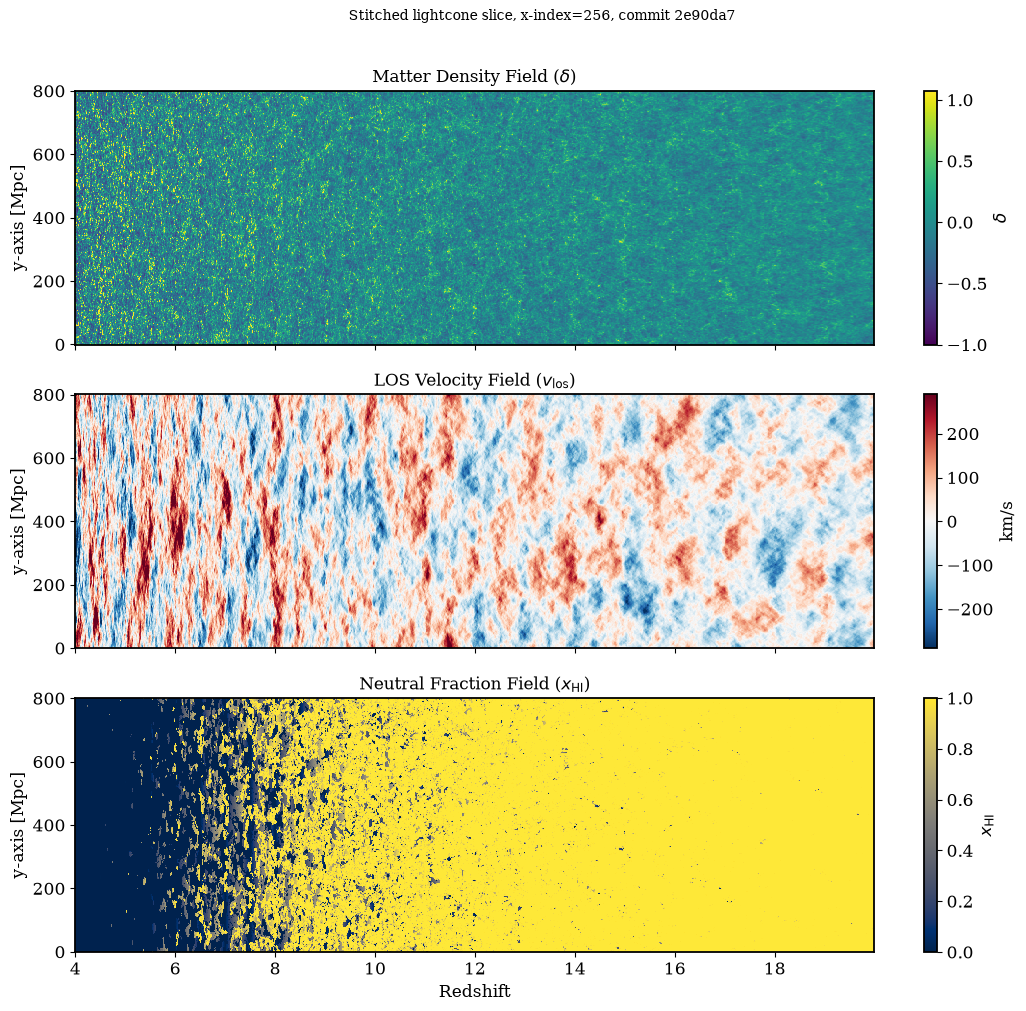

In [22]:
from ksz_pipeline.utils.constants import MPC_CM

z_arr_slice   = stitched_slice['z_arr']
box_len_slice = float(stitched_slice['box_len'])
delta_slice   = stitched_slice['delta']        # raw delta, NOT 1+delta
v_los_slice   = stitched_slice['v_los_Mpc_s']
xHI_slice     = stitched_slice['xHI']

v_los_km_s = v_los_slice * MPC_CM / 1e5   # Mpc/s -> cm/s -> km/s, for readability
y_axis_mpc = np.linspace(0, box_len_slice, delta_slice.shape[0])

fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)

vmax_delta = np.percentile(delta_slice, 99)
im0 = axes[0].pcolormesh(z_arr_slice, y_axis_mpc, delta_slice, cmap='viridis',
                          vmin=-1, vmax=vmax_delta, shading='auto')
axes[0].set_ylabel("y-axis [Mpc]")
axes[0].set_title(r"Matter Density Field ($\delta$)", fontsize=12)
fig.colorbar(im0, ax=axes[0]).set_label(r"$\delta$")

vmax_v = np.percentile(np.abs(v_los_km_s), 99)
im1 = axes[1].pcolormesh(z_arr_slice, y_axis_mpc, v_los_km_s, cmap='RdBu_r',
                          vmin=-vmax_v, vmax=vmax_v, shading='auto')
axes[1].set_ylabel("y-axis [Mpc]")
axes[1].set_title(r"LOS Velocity Field ($v_{\rm los}$)", fontsize=12)
fig.colorbar(im1, ax=axes[1]).set_label("km/s")

im2 = axes[2].pcolormesh(z_arr_slice, y_axis_mpc, xHI_slice, cmap='cividis',
                          vmin=0, vmax=1, shading='auto')
axes[2].set_ylabel("y-axis [Mpc]")
axes[2].set_xlabel("Redshift")
axes[2].set_title(r"Neutral Fraction Field ($x_{\rm HI}$)", fontsize=12)
fig.colorbar(im2, ax=axes[2]).set_label(r"$x_{\rm HI}$")

fig.suptitle(f"Stitched lightcone slice, x-index={int(stitched_slice['x_slice_idx'])}, "
             f"commit {run_stats['commit'][:7]}", fontsize=10, y=1.01)
fig.tight_layout()
fig.savefig(f"{PLOTS_DIR}/stitched_field_lightcone_slice.pdf", bbox_inches='tight')
print(f"Saved -> {PLOTS_DIR}/stitched_field_lightcone_slice.pdf")

Saved -> ../../data/plots/ksz_map_stitched.pdf

Map mean : 1.6910e-06
Map RMS  : 2.5976e-06


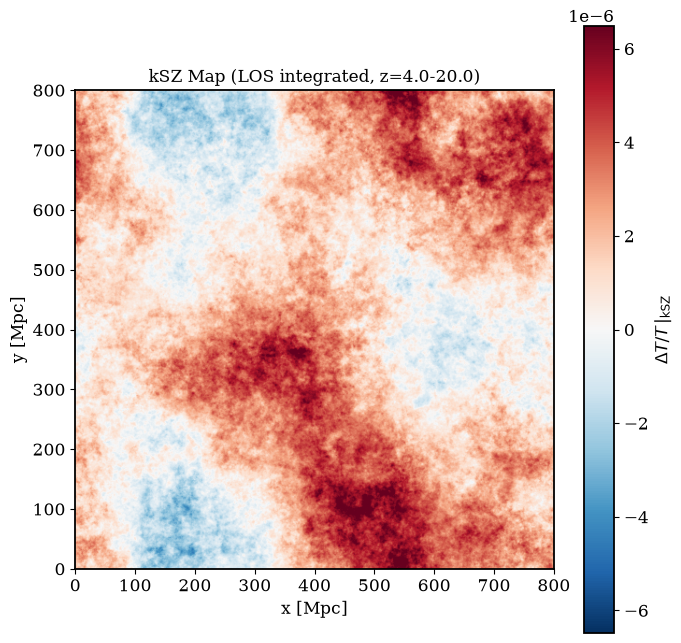

In [21]:
fig, ax = plt.subplots(figsize=(7, 7.5))

vmax_map = np.percentile(np.abs(ksz_map), 99.5)
im = ax.imshow(ksz_map, origin='lower', cmap='RdBu_r', vmin=-vmax_map, vmax=vmax_map,
               extent=[0, box_len_slice, 0, box_len_slice])
ax.set_xlabel("x [Mpc]")
ax.set_ylabel("y [Mpc]")
ax.set_title(f"kSZ Map (LOS integrated, z={run_stats['z_min']:.1f}-{run_stats['z_max']:.1f})", fontsize=12)
fig.colorbar(im, ax=ax, shrink=0.85).set_label(r"$\Delta T/T\,|_{\rm kSZ}$")

fig.tight_layout()
fig.savefig(f"{PLOTS_DIR}/ksz_map_stitched.pdf", bbox_inches='tight')
print(f"Saved -> {PLOTS_DIR}/ksz_map_stitched.pdf")

print(f"\nMap mean : {run_stats['ksz_map_mean']:.4e}")
print(f"Map RMS  : {run_stats['ksz_map_rms']:.4e}")